# Energy Analysis

**Objectives:** 

This notebook aims to 
- Identify the key drivers of DER adoption
- Produce consistent and comparable adoption metrics
- Cluster LGAs into adoption profiles
- Deliver a Power BI dashboard that provides intuitive, data-driven insights for decision-makers

**Key Outputs:**

1. LGAs segmented into distinct adoption profiles based on DER capacity and connection characteristics, enabling clearer identification of high-growth and emerging regions.
2. DER adoption intensity (capacity per capita and per business) tends to be higher in suburban and regional areas, with comparatively lower penetration in dense metropolitan LGAs, indicating differing economic and infrastructure drivers.
3. The Power BI analytics dashboard provides an integrated view of DER adoption and socioeconomic indicators, enabling targeted sales strategies, market prioritization, and evidence-based policy planning.


**Data:**

Data is initially taken from three sources (ABS,AEMO and geographical mapping) and processed into three fact tables. Each table is indexed by year and LGA. 
- Q_Main_Derr: Aggregate AEMO DER data by LGA and year then joining LGA via postcode.
- Q_Population_Agg: Population data including population, median age, income, education levels in long form. 
- Q_Business_Agg: Economic data table including counts for business sectors and business size in long form. 
More details can be found in the README.md file. 

In [46]:
import sqlite3 as sql
import pandas as pd

import numpy as np
np.random.seed(42)
np.seterr(divide='ignore', over='ignore', invalid='ignore') # Ignore divide by 0 warnings


from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA


In [47]:
#  --- Load datasets from SQLite database --- #

DB_PATH = "../data/sql_db/Energy.db"

conn = sql.connect(DB_PATH)

# Main dataset with Capacity, Number of Connections per Population/Businesses
derr_df = pd.read_sql_query("SELECT * FROM Fact_Derr", conn)

# Auxiliary data set containing demographic and socioeconomic data
population_df = pd.read_sql_query("SELECT * FROM Fact_Population", conn)
economy_df = pd.read_sql_query("SELECT * FROM Fact_Economic", conn)

conn.close()

## Exploratory Data Analysis

 We check the following in the dataset:
 - invalid entries in columns,
 - inconsistent counts in number of total businesses and number for each sector or size grouping,
 - distribution of features and 
 - correlation between columns. 



### Invalid Entries

We first investigate invalid entries in the aggregated AEMO DERR data. 

Checking the NAs shows that LGA column contains five NA rows. 


In [48]:
#  --- Check NaNs --- #
print("NA:Check")
print(" ------- ")
print(derr_df.isna().sum())

NA:Check
 ------- 
Year                   0
Lga                    5
Type                   0
TotalCapacity          0
BatteryCapacity        0
SolarCapacity          0
OtherCapacity          0
TotalDerConnections    0
BatteryConnections     0
SolarConnections       0
OtherConnections       0
dtype: int64


The five rows correspond to aggregate data for NA LGA's over 5 years. With no way to recover these LGA, we propose to remove them in the analysis. 

In [49]:
derr_df[derr_df['Lga'].isna()]

,Year,Lga,Type,TotalCapacity,BatteryCapacity,SolarCapacity,OtherCapacity,TotalDerConnections,BatteryConnections,SolarConnections,OtherConnections
0,2021,NaN,RESIDENTIAL,1663.62,0.0,1663.62,0.0,400.0,0.0,400.0,0.0
1,2022,NaN,RESIDENTIAL,1949.12,64.6,1884.52,0.0,442.0,7.0,435.0,0.0
2,2023,NaN,RESIDENTIAL,2008.00,73.8,1934.20,0.0,450.0,9.0,441.0,0.0
3,2024,NaN,RESIDENTIAL,1580.80,69.2,1511.60,0.0,337.0,8.0,329.0,0.0
4,2025,NaN,RESIDENTIAL,322.00,40.0,282.00,0.0,80.0,4.0,76.0,0.0


The type column contains entries such as 'blank' and 'NoClassification'. Printing out LGAs with these rows indicates that LGAs and years with (blank) all contain 'RESIDENTIAL' and "BUSINESS' types. This is confirmed by checking the proportion of these entries.


In [50]:
# --- LGAs with 'Blank' in Type Column --- #

problem_lga_year = derr_df[derr_df['Type']=='(blank)']
derr_blank_df = derr_df.merge(problem_lga_year[['Lga','Year']], on=['Lga','Year']).sort_values(['Lga','Year'])

# Print out rows with type entry '(blank)'
print(derr_blank_df.head(6))

# Confirm that all LGAs with (blank) also contains BUSINESS and RESIDENTIAL entries 
three_entries = np.mean(derr_blank_df.groupby(['Lga','Year']).count()['Type'].values == 3)
print("Number of LGA with three type entries: " + str(three_entries))


   Year      Lga         Type  TotalCapacity  BatteryCapacity  SolarCapacity  \
0  2025  10470.0      (blank)        201.200           26.000        175.200   
1  2025  10470.0     BUSINESS      41510.640          236.600      41274.240   
2  2025  10470.0  RESIDENTIAL     219903.410        13600.798     206302.012   
3  2023  10750.0      (blank)        429.800            0.000        429.800   
4  2023  10750.0     BUSINESS     139133.260            0.000     137136.660   
5  2023  10750.0  RESIDENTIAL    1383786.248           20.000    1383373.248   

   OtherCapacity  TotalDerConnections  BatteryConnections  SolarConnections  \
0            0.0                 20.0                 2.0              20.0   
1            0.0               2298.0                28.0            2298.0   
2            0.0              41160.0              1764.0           40736.0   
3            0.0                 52.0                 0.0              52.0   
4         1996.6               7598.0       

Rows with type 'NoClassification' do not appear with counterpart 'RESIDENTIAL' and 'BUSINESS' entries. 

In [51]:
# --- LGAs with 'NoClassification' in Type Column --- #

problem_lga_year = derr_df[derr_df['Type']=='NoClassification']
derr_nc_df = derr_df.merge(problem_lga_year[['Lga','Year']], on=['Lga','Year']).sort_values(by = ['Lga','Year'])

# Print out rows with type entry 'NoCLassification'
print(derr_nc_df.head(6))

   Year      Lga              Type  TotalCapacity  BatteryCapacity  \
0  2021  50080.0  NoClassification        20453.2            161.2   
1  2021  50210.0  NoClassification       336713.8           1139.4   
2  2021  50280.0  NoClassification        39013.3            512.1   
3  2021  50350.0  NoClassification       122810.5            312.2   
4  2021  50420.0  NoClassification       119388.1            483.7   
5  2021  50490.0  NoClassification       134820.3            437.1   

   SolarCapacity  OtherCapacity  TotalDerConnections  BatteryConnections  \
0        18812.6         1479.5               5849.0                28.0   
1       327157.9         8416.4              52032.0               277.0   
2        36436.9         2064.0               6978.0               109.0   
3       114393.8         8104.5              14432.0                64.0   
4       114600.2         4304.2              17808.0                99.0   
5       122279.9        12103.2              18071.0 

Next we check the invalid entries in the population dataframe. The number of NA entries for several columns is around 2100. 

In [52]:
#  --- Check NAs --- #
print("NA:Check")
print(" ------- ")
print(population_df.isna().sum())


NA:Check
 ------- 
Lga                                    0
Year                                   0
TotalPopulation                        0
PopulationDensity                    206
MedianAge                              0
MedianEquivalisedHouseholdIncome    2188
Certificate                         2189
AdvDiploma                          2189
BachelorDegree                      2189
GraduateDiploma                     2207
Postgraduate                        2207
dtype: int64


These NAs arise out of the source data bing census data and therefore only collected every four years. We confirm this by checking the dataframe for any given LGA. 

In [53]:
# --- NAs in Population Data --- #
index = population_df['Lga']==10050
population_df.loc[index]

,Lga,Year,TotalPopulation,PopulationDensity,MedianAge,MedianEquivalisedHouseholdIncome,Certificate,AdvDiploma,BachelorDegree,GraduateDiploma,Postgraduate
0,10050,2020,55466.0,181.5,38.5,NaN,NaN,NaN,NaN,NaN,NaN
1,10050,2021,56067.0,183.4,39.1,947.0,24.0,9.2,13.1,2.4,3.7
2,10050,2022,56665.0,185.4,39.2,NaN,NaN,NaN,NaN,NaN,NaN
3,10050,2023,57509.0,188.2,39.3,NaN,NaN,NaN,NaN,NaN,NaN
4,10050,2024,58317.0,190.8,39.3,NaN,NaN,NaN,NaN,NaN,NaN


Finally, we check the invalid entries in businesses data. Below, we detect no NAs entries in any columns of the dataframe.

In [54]:
#  --- Check NaNs --- #
print("NA:Check")
print(" ------- ")
print(economy_df.isna().sum())


NA:Check
 ------- 
Lga                   0
Year                  0
TotalBusinesses       0
PrimaryIndustry       0
SecondaryIndustry     0
TertiaryIndustry      0
QuaternaryIndustry    0
SmallBusinesses       0
MediumBusinesses      0
LargeBusinesses       0
dtype: int64


We need to check that the total business counts are consistent with the business counts within each group (both sector and business size). Here, we plot a histogram of the difference between the sum of businesses in each sector and the total reported number of businesses. We also plot the error margin equal to 0.05 of the total number of business counts. 

Index(['PrimaryIndustry', 'SecondaryIndustry', 'TertiaryIndustry',
       'QuaternaryIndustry'],
      dtype='object')
0.9074954296160878


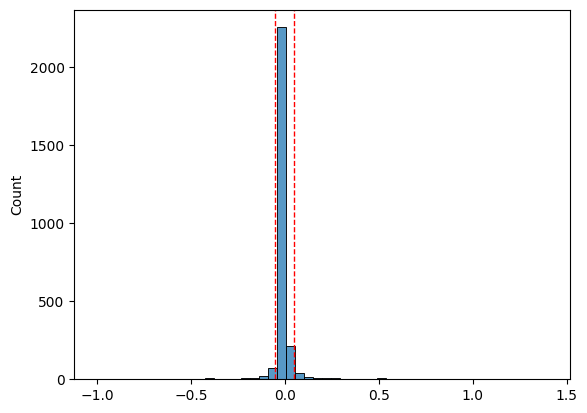

In [55]:
# --- Sector Counts --- #
threshold = 0.05

print(economy_df.columns[3:7])

# Look for mismatches in business sectors data total and sum of sectors
businesss_count = economy_df[economy_df.columns[3:7]].sum(axis=1)
businesss_total = economy_df['TotalBusinesses']
sector_discrepency = (businesss_count-businesss_total)/businesss_total

print((abs(sector_discrepency)<0.05).mean())

sns.histplot(sector_discrepency,bins=50)
plt.axvline(x=threshold, color='red', linestyle='--', linewidth=1, label='Threshold = 0.05')
plt.axvline(x=-threshold, color='red', linestyle='--', linewidth=1, label='Threshold = 0.05')
plt.show()


The plot histogram shows most of the discrepancies are below the threshold. To ensure that there are no obvious outlier points, we plot the sum of businesses in each sector against the total reported umber of businesses as well as a red line indicating equality. 

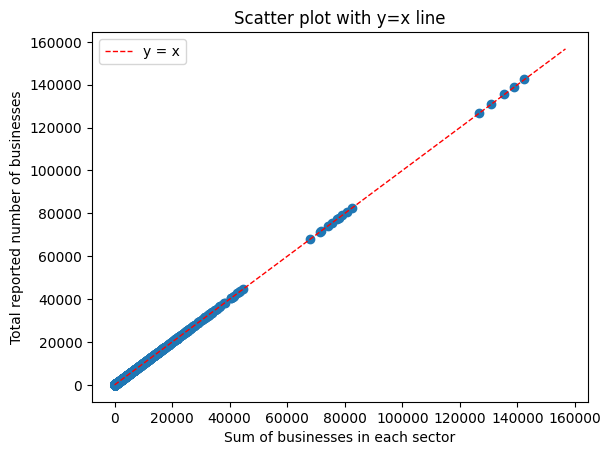

In [56]:
plt.scatter(x=businesss_count,y=businesss_total)

lims = [min(businesss_count), max(businesss_count*1.1)]  # adjust based on your data range
plt.plot(lims, lims, color='red', linestyle='--', linewidth=1, label='y = x')

plt.xlabel('Sum of businesses in each sector')
plt.ylabel('Total reported number of businesses')
plt.title('Scatter plot with y=x line')
plt.legend()
plt.show()

The plot above shows that most points lie close to the line and no outliers are present. 

Similar to the above, we again plot a histogram of the difference between the sum of businesses in each size group and the total reported number of businesses.

Index(['SmallBusinesses', 'MediumBusinesses', 'LargeBusinesses'], dtype='object')
0.9297989031078611


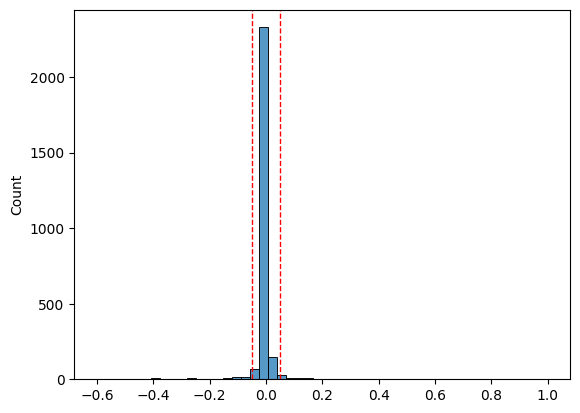

In [57]:
# --- Size Counts --- #

# Columns 
print(economy_df.columns[7:])

# Look for mismatches in business size data total and sum of sizes
businesss_count = economy_df[economy_df.columns[7:]].sum(axis=1)
businesss_total = economy_df['TotalBusinesses']
size_discrepency = (businesss_count-businesss_total)/businesss_total

print((abs(size_discrepency)<0.05).mean())

sns.histplot(size_discrepency,bins=50)
plt.axvline(x=threshold, color='red', linestyle='--', linewidth=1, label='Threshold = 0.05')
plt.axvline(x=-threshold, color='red', linestyle='--', linewidth=1, label='Threshold = 0.05')
plt.show()

Again, most differences lie within the 0.05 error threshold. Next we plot these values as a scatter plot to detect outliers.  

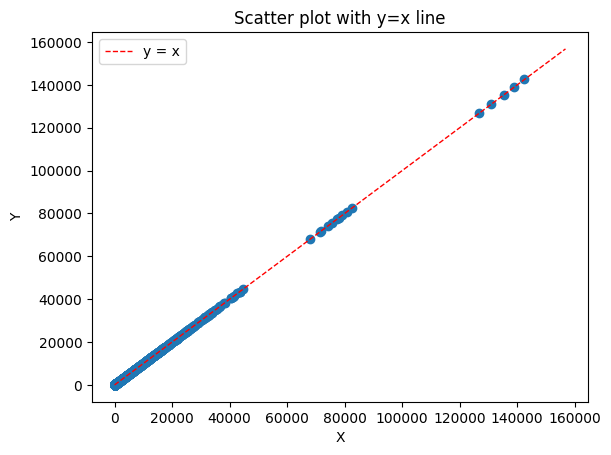

In [58]:
plt.scatter(x=businesss_count,y=businesss_total)

lims = [min(businesss_count), max(businesss_count*1.1)]  # adjust based on your data range
plt.plot(lims, lims, color='red', linestyle='--', linewidth=1, label='y = x')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scatter plot with y=x line')
plt.legend()
plt.show()

Again, no outliers are present. 

For both sector and business size, the following processing should be done. If discrepancy is less than 5% of total business number, fill NAs with 0. For the remaining rows, drop LGA. 

### Distributions 

Here, the distribution of each column is checked. 

At this point, the dataset is separated into residential data and business data.
- The residential data denoted by `res_df` comprises of DERR data with 'type' being residential and ABS population data, both aggregated by year and LGA. 
- The business data `bus_df` comprises of DERR data with 'type' being business and ABS economic data, both aggregated by year and LGA. 



In [59]:
# --- Create separate business and residential datasets --- #
res_df = derr_df[derr_df['Type']=="RESIDENTIAL"].drop(labels=['Type'], axis=1)
bus_df = derr_df[derr_df['Type']=="BUSINESS"].drop(labels='Type', axis=1)

# Combine residential derr data with ABS population data 
res_df = res_df.merge(
    right=population_df,
    how = 'left',
    on = ['Year','Lga']
    )

# Combine business derr data with ABS economic data 
bus_df = bus_df.merge(
    right=economy_df,
    how = 'left',
    on = ['Year','Lga']
)


The distribution of columns from the residential data is shown below where we observe:
- heavily skewed capacity and number of connections,
- heavily skewed total population and population density, 
- median income and age are a slightly skewed normally distributed. 

This indicates that a transformation may need to be utilised for most columns. 

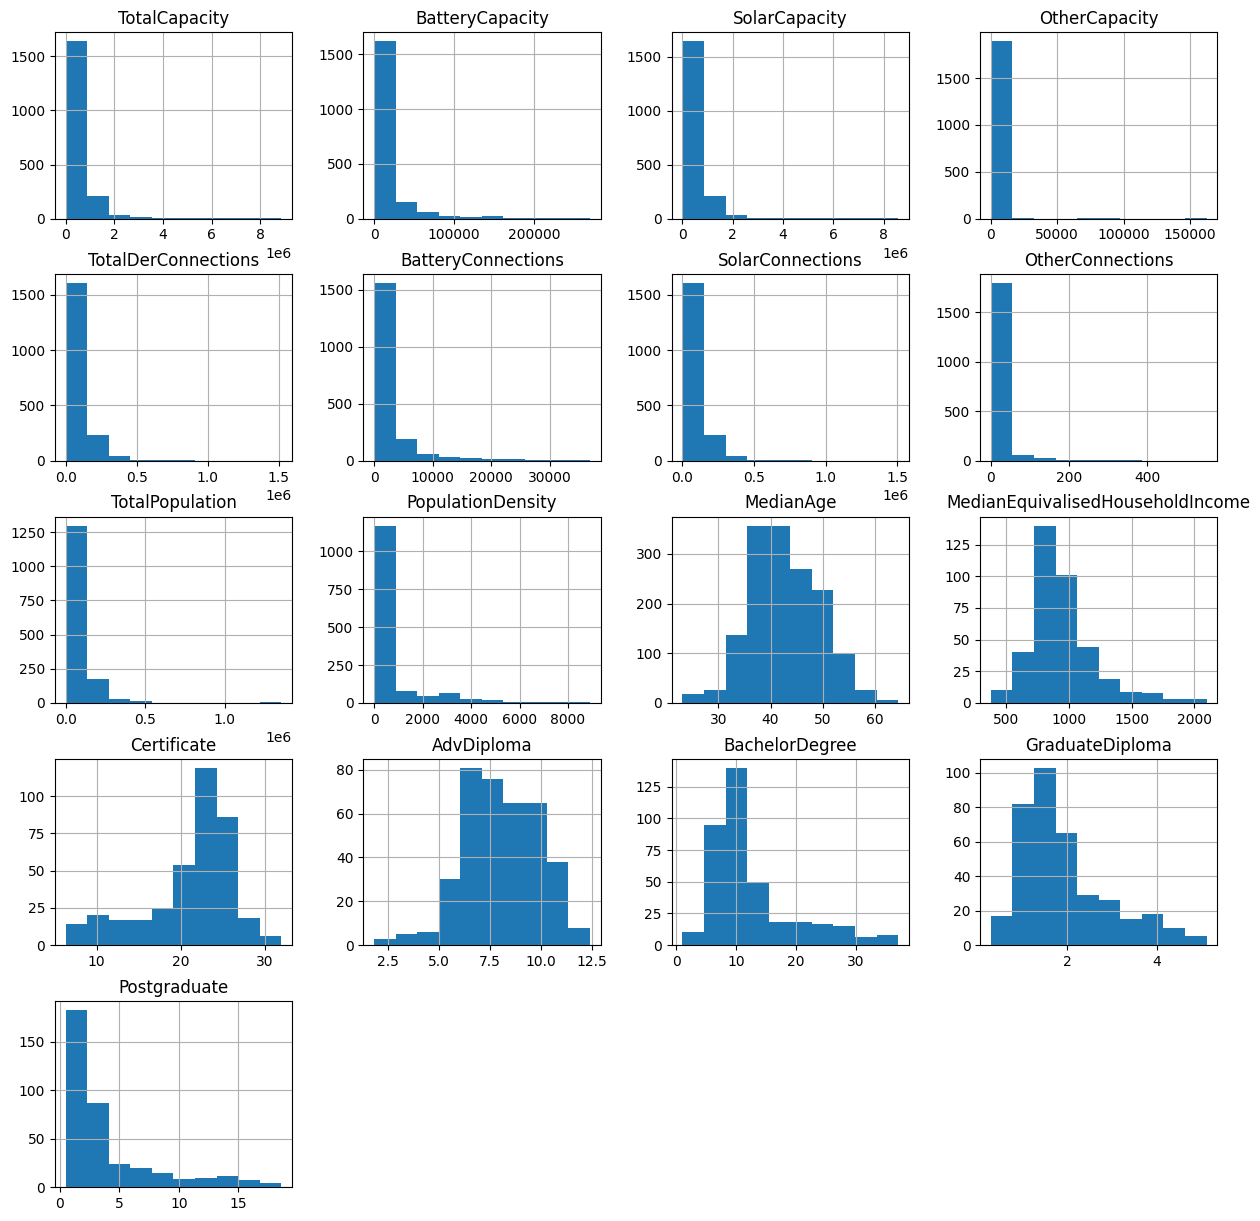

In [60]:
# Plot histogram of residential dataset
_ = res_df.drop(['Lga','Year'],axis=1).hist(figsize=(15,15))
plt.show()

The distribution of columns from the business data is shown below. 

The distribution of columns from the residential data is shown below where we observe:
- capacity and number of connections are heavily skewed. 
- economic data is also heavily skewed. 

This indicates that a transformation may need to be utilised for most columns. 

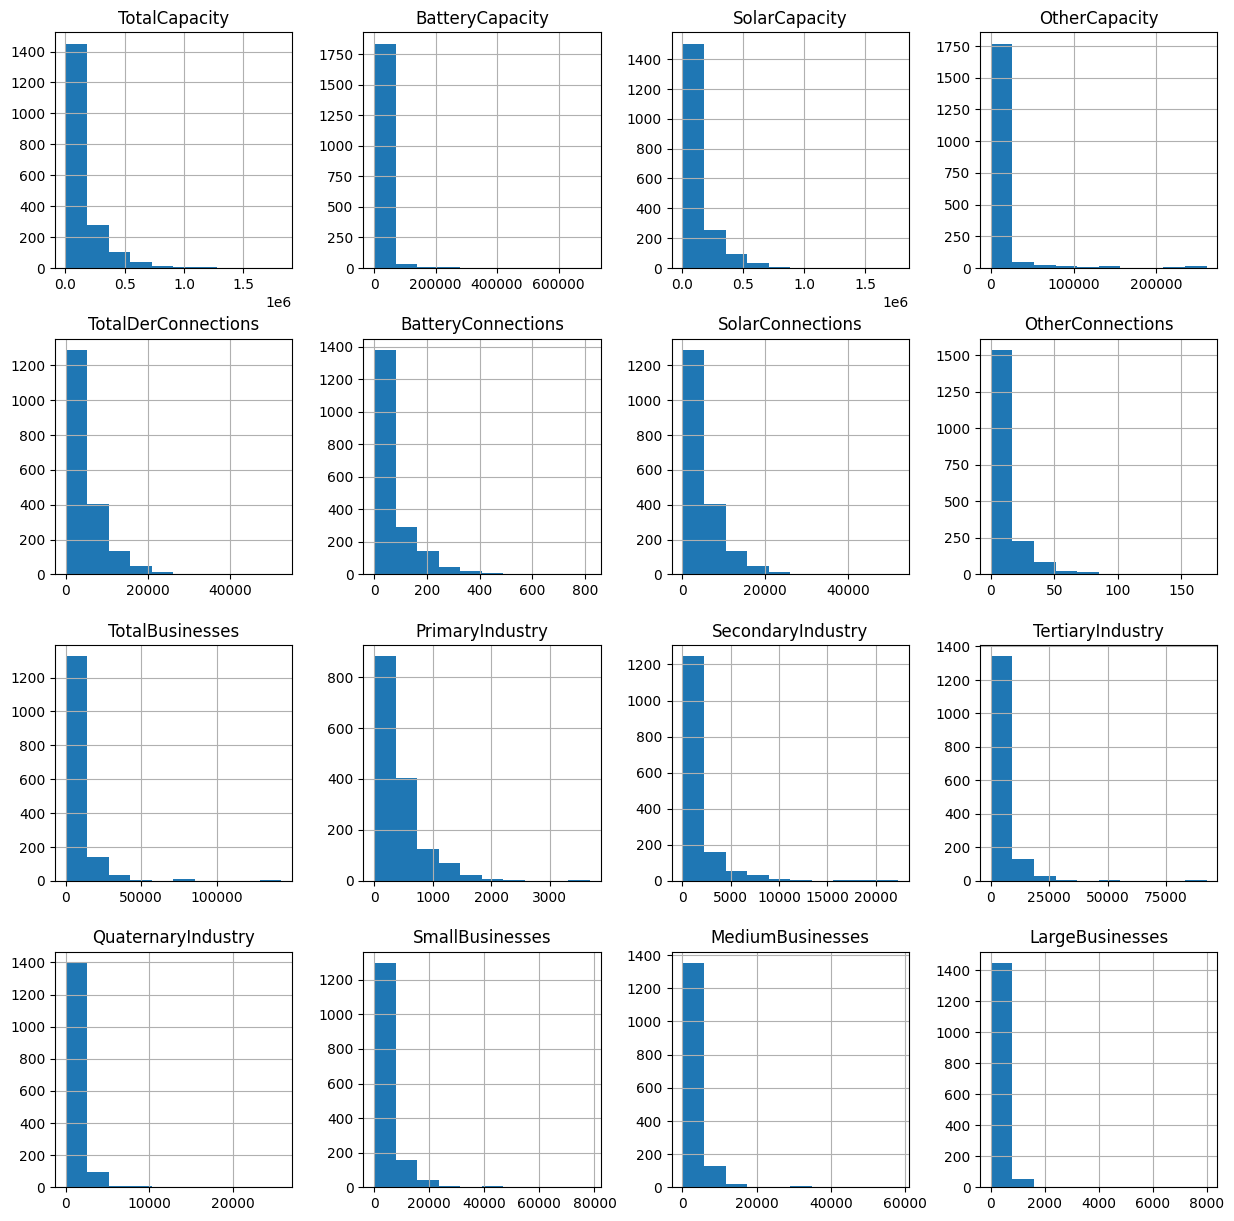

In [61]:
# Plot histogram of business dataset
_ = bus_df.drop(['Lga','Year'],axis=1).hist(figsize=(15,15))
plt.show()

### Correlation

The correlation between the variables calculated below. Since several of the variables are skewed we will apply a log transformation to the data before calculating correlation.

In [62]:
### --- Define function used to plot correlation heatmap--- #

def plot_corr(dataframe: pd.DataFrame, target: str, transform_list:list):
    # Apply boxcox transformation on skewed columns
    
    df = dataframe.copy()
    
    for col in transform_list:
        df.loc[:,col] = np.log(df[col])

    # Correlation heatmap
    corr_data = df.copy()
    corr_matrix = corr_data[corr_data.columns[2:]].corr()
    
    # Plot heatmap 
    fig, ax = plt.subplots(1, figsize= (10,8))
    sns.heatmap(corr_matrix,annot=True,cmap=sns.color_palette("crest", as_cmap=True),ax = ax)
    plt.tight_layout()
    
    return fig, ax
    


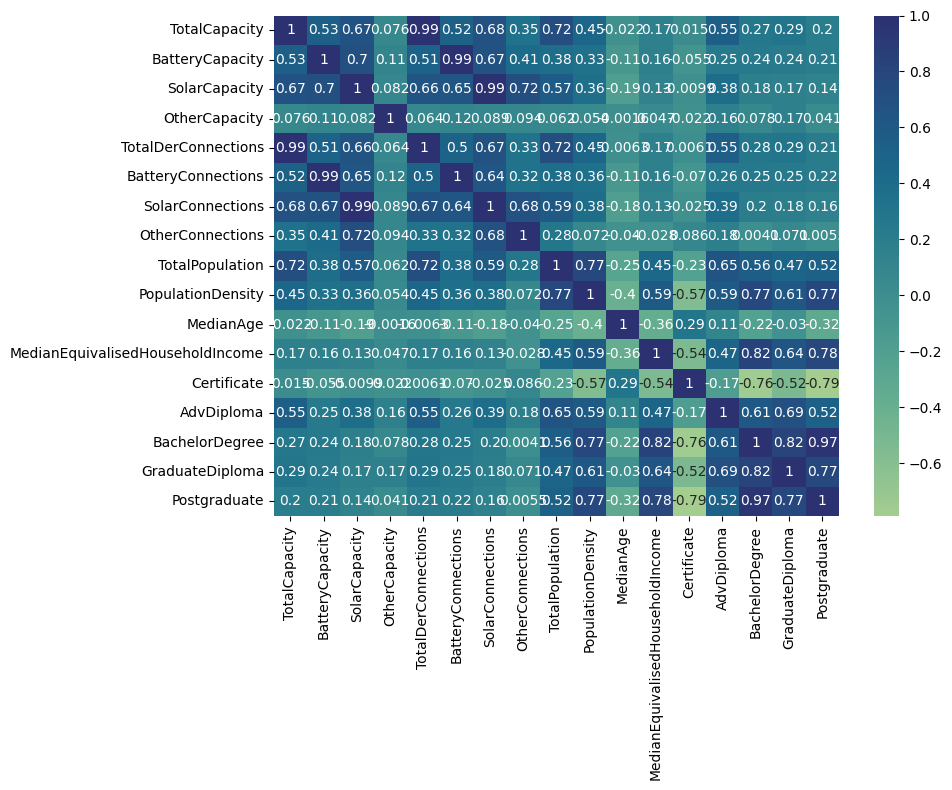

In [63]:
# --- Plot correlation heatmap for residential data --- #

target = 'TotalCapacity'
normalise_cols = ['TotalCapacity',
                  'TotalDerConnections',
                  'TotalPopulation',
                  'PopulationDensity'
                  ]

fig, ax = plot_corr(res_df,target,normalise_cols)

We observe:
- very high correlation between total capacity, battery capacity, total connections and solar connections (>0.9). In fact, solar capacity dominates total capacity. 
- high correlation of total capacity with LGA population. We see the not too surprising effect of the size of LGA driving total DER capacity.

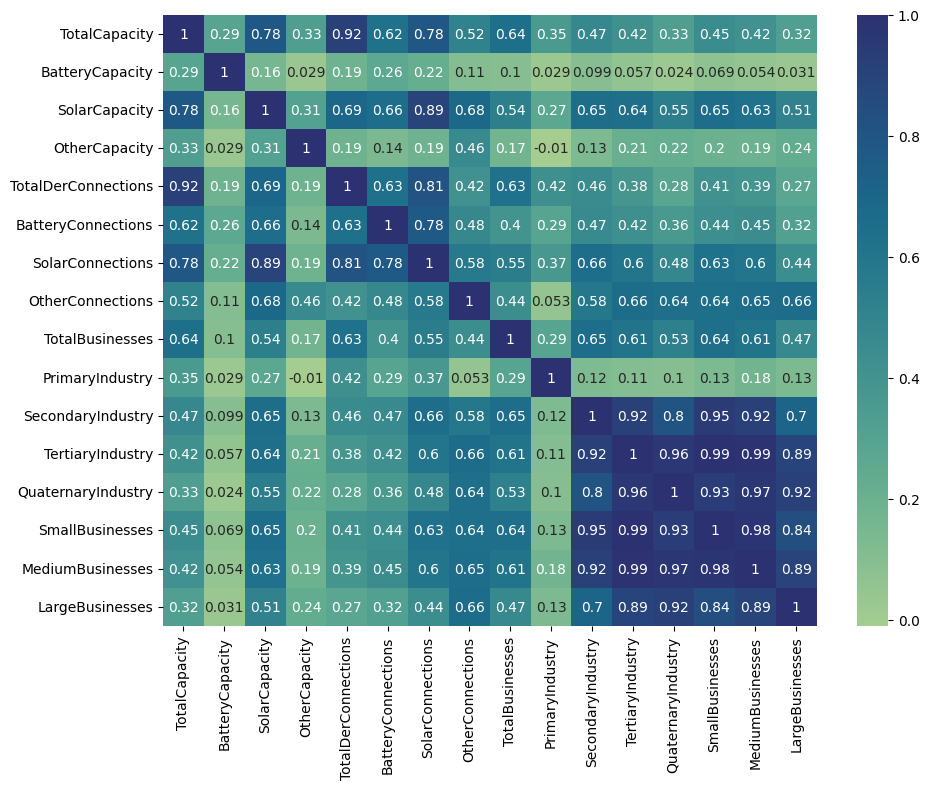

In [64]:
# --- Plot correlation heatmap for business data --- #

target = 'TotalCapacity'
normalise_cols = [
                'TotalCapacity',
                'TotalDerConnections',
                'TotalBusinesses'                  ]

fig, ax = plot_corr(bus_df,target,normalise_cols)

We observe:
- Very high correlation between total capacity and solar capacity (>0.9). 
- Moderate correlation of total capacity with small and medium businesses and secondary and tertiary industries. May indicate a metropolitan vs rural divide. 


## Data Processing 


DER Fact Table: 
- Dropped 'None' and 'Blank' entries in 'Type' column in DERR data. 
- Remove misaligned LGAs and recorded their codes in SQL table.
- Filter out 2025 since year is incomplete. 

Population and Economic Fact Tables: 
- Forwardfill followed by backfill population data. With the exception of the first year, each year corresponds to data from the last reported census. 
- Processed mismatches in total number of businesses and sum of business sectors. If discrepancy is less than 5% of total business number, fill NAs with 0. For the remaining rows, drop LGA. 

In [65]:
# ---  Clean data --- #

derr_clean = derr_df.copy()
population_clean = population_df.copy()
economy_clean = economy_df.copy()

# Change '(blank)' rows to NaN
filter_blank = derr_clean['Type'] == '(blank)'
derr_clean.loc[filter_blank,['Type']] = None

# Change 'NoClassification' to NaN
filter_noclass = derr_clean['Type'] == 'NoClassification'
problem_lga = list(set((derr_clean.loc[filter_noclass,['Lga']].values).flatten()))
derr_clean.loc[filter_noclass,['Type']] = None

# Drop NaNs from type
derr_clean.dropna(subset = ['Type'], inplace=True)

# Drop Nans in LGA (due to aggregate at state level)
derr_clean.dropna(subset = ['Lga'], inplace=True)

# Forward fill then backfill to impute missing values in population data 
population_clean.sort_values(by=['Lga','Year'],inplace=True)
cols = list(population_clean.columns)
cols.remove('Lga')

population_clean[cols] = (
    population_clean.groupby('Lga')
    .ffill()
    .bfill()
    )


# Remove 2025 year 
filter_2025 = derr_clean['Year']==2025 # Socioeconomic data does not cover 2025

res_filter = derr_clean['Type']=='RESIDENTIAL'
bus_filter = derr_clean['Type']=='BUSINESS'


In [66]:
# --- Create separate residential and business data  --- #


# Create residential data 

res_df = derr_clean.loc[~filter_2025 & res_filter,:].copy()

res_df = res_df.merge(
    right = population_clean,
    how='left',
    on=['Lga','Year']
    )

# Create business data 

bus_df = derr_clean.loc[~filter_2025 & bus_filter,:].copy()

bus_df = bus_df.merge(
    right = economy_clean,
    how = 'left',
    on=['Lga','Year']
)           

# Aggregate by year
agg_res_df = res_df.groupby(['Lga']).mean(numeric_only=True).drop('Year',axis=1).reset_index()
agg_bus_df = bus_df.groupby(['Lga']).mean(numeric_only=True).drop('Year',axis=1).reset_index()


## Feature Selection

This section processes the features utilised in the clustering analysis and ultimetly in the powerBI dashboard. The main two modifications are as follows:
1. To remove LGA size as a driver to DER adoption, capaciry per capita and connections per capaita are used for both the residential and business dagtasets. Per capacity in the business set here referes to per business. 
2. A metric for growth rate for each LGA is calculated. The growth rate is the slope obtained by a simple linear regression over the four years (2021-2024).

In [67]:
from sklearn.linear_model import LinearRegression

def cal_growth(df:pd.DataFrame):
    growth = {}

    for lga, group in df.groupby("Lga"):
        X = (group["Year"] - group["Year"].min()).values.reshape(-1, 1)
        y = group["CapacityPerCapita"].values
        model = LinearRegression().fit(X, y)
        growth[lga] = model.coef_[0]   # slope

    df_growth = (
        pd.DataFrame.from_dict(growth, orient="index", columns=["GrowthRate"])
        .reset_index()
        .rename(columns={"index": "Lga"})
    )

    return df_growth

In [68]:
# Select Total columns 
id_cols = (res_df.columns[:3]).to_list()
derr_kept_cols = ['TotalCapacity','TotalDerConnections']

res_cols = id_cols + derr_kept_cols + [col for col in population_clean.columns if col not in id_cols]
bus_cols =  id_cols + derr_kept_cols + [col for col in economy_clean.columns if col not in id_cols]

res_norm_df = res_df.loc[:,res_cols].copy()
bus_norm_df = bus_df.loc[:,bus_cols].copy()

# --- Calculate New Features --- #

# Capacity Per Connections
res_norm_df['CapacityPerConnection'] =(
    res_norm_df['TotalCapacity'] /
    res_norm_df['TotalDerConnections']
    )
bus_norm_df['CapacityPerConnection'] = (
    bus_norm_df['TotalCapacity'] /
    bus_norm_df['TotalDerConnections']
    )


# Capacity Per Capita/Businesses 
res_norm_df['CapacityPerCapita'] = (
    res_norm_df['TotalCapacity'] / 
    res_norm_df['TotalPopulation']
    )
bus_norm_df['CapacityPerCapita'] = (
    bus_norm_df['TotalCapacity'] /
    bus_norm_df['TotalBusinesses'].replace(0, np.nan)
    ).fillna(0)



# Change number of businesses to proportion
cols = [col for col in economy_clean.columns if col not in id_cols]
print(cols)
cols.remove('TotalBusinesses')
bus_norm_df.loc[:,cols] = (
    bus_norm_df.loc[:,cols]
    .divide(bus_norm_df['TotalBusinesses'].replace(0, np.nan),axis=0)
    ).fillna(0)
    
# Growth 
res_growth = cal_growth(res_norm_df)
bus_growth = cal_growth(bus_norm_df)


# --- Aggregation by Year --- #

res_norm_df = res_norm_df.groupby(['Lga','Type']).mean().drop('Year',axis=1).reset_index()
bus_norm_df = bus_norm_df.groupby(['Lga','Type']).mean().drop('Year',axis=1).reset_index()

# Merge with growth factor 

res_norm_df = res_norm_df.merge(
    right=res_growth,
    how='left',
    on='Lga'
    )

bus_norm_df = bus_norm_df.merge(
    right=bus_growth,
    how='left',
    on='Lga'
    )

# Save dataframes
processed_path = "../data/processed"
res_norm_df.to_parquet(processed_path+"/res_data.parquet")
bus_norm_df.to_parquet(processed_path+"/bus_data.parquet")


['TotalBusinesses', 'PrimaryIndustry', 'SecondaryIndustry', 'TertiaryIndustry', 'QuaternaryIndustry', 'SmallBusinesses', 'MediumBusinesses', 'LargeBusinesses']


## Market Segmentation

KMeans clustering is applied for market segmentation. Four clusters for both residential and business DERR data are fitted. The variables used in clustering are  
- 'TotalCapacity',
- 'TotalDerConnections',
- 'CapacityPerCapita',
- 'CapacityPerConnection' and
- 'GrowthRate'.

Projecting these clusters onto principle components characterises the clusters which will be used as descriptors in the dashboard. Unfortunately, projecting the clusters onto socioeconomic factors do not reveal any obvious link between such factors and each cluster. 

In [69]:
# Copy data with per capita columns
res_df = res_norm_df.copy()
bus_df = bus_norm_df.copy()

### Optimal Number of Clusters

Elbow method is used to determine the optimal number of clusters. 

In [70]:
# --- Define function to plot distortion of clusters --- #

def cluster_elbow(dataframe: pd.DataFrame, variable_list: list):
    
    # Prepare data
    df = dataframe.copy()
    
    df = df[['Lga']+variable_list]
    X = df[df.columns[1:]].values

    # Hyper parameter tuning using elbow method with distorsion as a metric 

    k_groups = range(1,10)
    distorsion = []

    for k in k_groups:

        kmeans = KMeans(
            n_clusters = k,
            random_state=42
        ).fit(X)
            
        distorsion.append(sum(np.min(cdist(X, kmeans.cluster_centers_, 'euclidean'), axis=1)**2) / X.shape[0])
        

    plt.plot(k_groups, distorsion, 'bx-')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Distortion')
    plt.title('The Elbow Method using Distortion')
    plt.show()
    

The following plot shows the distortion for residential data. The cutoff before diminishing returns occurs after 3-4 clusters.  

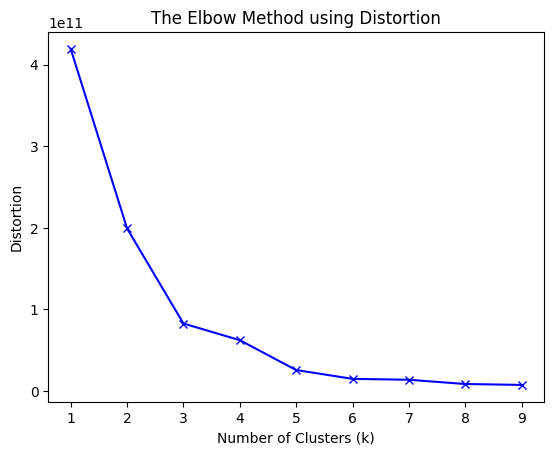

In [71]:
# --- Create distortion plot for residential data --- #

# Find optimal number of clusters for Kmeans
target_var_list = ['TotalCapacity',
                   'TotalDerConnections',
                   'CapacityPerCapita',
                   'CapacityPerConnection',
                   'GrowthRate']

cluster_elbow(res_df,target_var_list)


The following plot shows the distortion for business data. The cutoff before diminishing returns occurs after 3-4 clusters.  

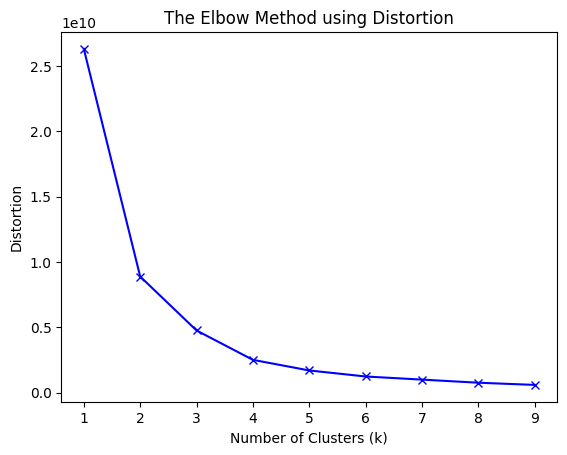

In [72]:
# --- Create distortion plot for business data --- #

cluster_elbow(bus_df,target_var_list)

In both cases, 3-4 clusters should be used for clustering. 

### Fit and Diagnostics 

In [73]:
# --- Function to carry out clustering and PCA projection --- #

def clustering(dataframe: pd.DataFrame, variable_list:list, n_clusters: int):
    '''
    Standardises target columns on variable_list and applies Kmeans with n_clusters. 
    Returns a dataframe with a new column corresponding to the row's assigned cluster. 
    '''
    
    # Prepare data 
    df = dataframe.copy()
    
    df = df[['Lga']+variable_list]
    X = df[df.columns[1:]].values
    
    scalar = StandardScaler()
    X = scalar.fit_transform(X)
    print("Standardised data using standard scalar.")
    
    # Clustering Results
    kmeans = KMeans(
        n_clusters = n_clusters,
        random_state=42
    ).fit(X)

    dataframe['Cluster'] = kmeans.labels_ # Save to original dataframe
    
    return dataframe



def principle_conponents(dataframe: pd.DataFrame,
                         variable_list: list,
                         index_name: str,
                         pca_conponents: int):
    
    X = dataframe[variable_list].values
    
    # Standardise
    scalar = StandardScaler()
    X = scalar.fit_transform(X)
    print("Standardised data using standard scalar.")

    # PCA 
    pca = PCA(n_components=pca_conponents)
    X_pca = pca.fit_transform(X)
    
    # Save results
    explained_var_ratio = pca.explained_variance_ratio_
    pca_vectors = pd.DataFrame(data=pca.components_,
                               columns=variable_list)
    df_transformed = pd.DataFrame(data=X_pca,
                                  index= dataframe[index_name],
                                  columns=[f'PC {i}' for i in range(1,pca_conponents+1)]
                                  )


    return df_transformed, pca_vectors, explained_var_ratio


A Kmeans clustering is applied to both residential and nd business data to identify distinct adoption profiles. 

Four clusters are fitted onto the residential and business data. The variables standardised are:
- TotalCapacity,
- TotalDerConnections,
- CapacityPerCapita,
- CapacityPerConnection and
- GrowthRate.

In [ ]:
# --- Cluster and PCA Residential Data --- #

# List variables to standardise
target_var_list = ['TotalCapacity',
                   'TotalDerConnections',
                   'CapacityPerCapita',
                   'CapacityPerConnection',
                   'GrowthRate']

# Apply clustering
res_df = clustering(res_df,target_var_list,4)

# Apply PCA to Residential Data 
res_pca, res_vecs , explained_var_ratio = principle_conponents(
                     dataframe = res_df,
                     variable_list= target_var_list,
                     index_name='Lga',
                     pca_conponents=3
                     )

print("Explained Variance Ratio:", str(sum(explained_var_ratio)))

Standardised data using standard scalar.
Standardised data using standard scalar.
Explained Variance Ratio: 0.9820382438903734


,TotalCapacity,TotalDerConnections,CapacityPerCapita,CapacityPerConnection,GrowthRate
0,0.534471,0.540810,-0.463962,-0.088575,-0.445824
1,0.459090,0.446092,0.487412,0.264448,0.531728
2,-0.052076,-0.101934,-0.255900,0.953666,-0.109242


In [ ]:
# --- Cluster and PCA Business Data --- #

# List variables to standardise
target_var_list = ['TotalCapacity',
                   'TotalDerConnections',
                   'CapacityPerCapita',
                   'CapacityPerConnection',
                   'GrowthRate']

# Apply clustering 
bus_df = clustering(bus_df,target_var_list,4)

# Apply PCA to Business Data
bus_pca, bus_vecs , explained_var_ratio = principle_conponents(
                     dataframe = bus_df,
                     variable_list= target_var_list,
                     index_name='Lga',
                     pca_conponents=3
                     )

print("Explained Variance Ratio:",str(sum(explained_var_ratio)))

Standardised data using standard scalar.
Standardised data using standard scalar.
Explained Variance Ratio: 0.9379455959926133


,TotalCapacity,TotalDerConnections,CapacityPerCapita,CapacityPerConnection,GrowthRate
0,0.653138,0.620782,-0.270008,0.239332,-0.240536
1,0.247616,0.189388,0.643530,0.224423,0.662059
2,-0.051163,-0.376948,-0.131259,0.913792,-0.055204


### Cluster Interpretation

To get a meaningful description of these clusters, we project the clusters onto 
- PCA factors
- DER factors and
- population/economic factors. 

In [76]:

def cluster_projection(df_pca:pd.DataFrame,df_cluster:pd.DataFrame,axis_x:int,axis_y:int):

    combined_df = pd.merge(
        left = df_pca,
        right= df_cluster[['Lga','Cluster']],
        on='Lga',
        how='inner'
    )
    
    # Project clusters on PCs
    plt.figure(figsize=(8, 6))
    
    # Get principle conponent labels
    pca_label_x = df_pca.columns[axis_x-1]
    pca_label_y = df_pca.columns[axis_y-1]

    # Create scatter plot
    unique_labels = np.unique(combined_df['Cluster'])
    for label in unique_labels:
        mask = combined_df['Cluster'] == label
        plt.scatter(
            combined_df.loc[mask, pca_label_x], combined_df.loc[mask, pca_label_y],
            label=f'Cluster {label}', alpha=0.7
        )

    plt.xlabel(f'Principal Component {pca_label_x}')
    plt.ylabel(f'Principal Component {pca_label_y}')
    plt.title('Clusters Projected on First Two Principal Components')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()
    

### Residential Data

The plot below shows the clusters in the residential data  projected onto the first and third principle components. 

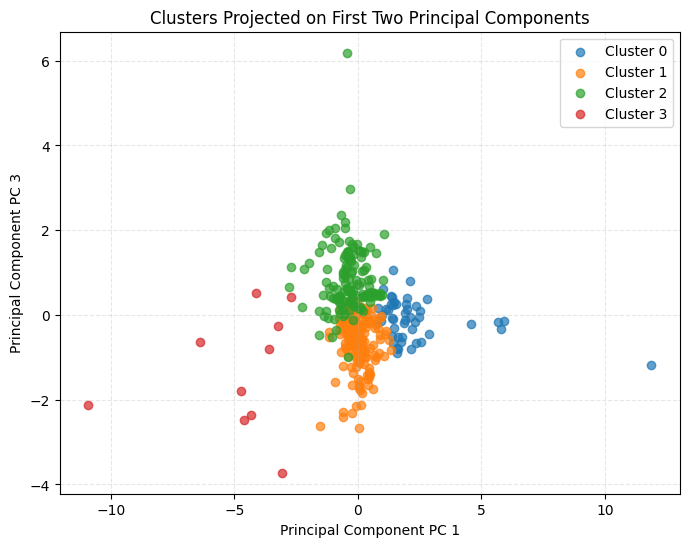

   TotalCapacity  TotalDerConnections  CapacityPerCapita  \
0       0.534471             0.540810          -0.463962   
1       0.459090             0.446092           0.487412   
2      -0.052076            -0.101934          -0.255900   

   CapacityPerConnection  GrowthRate  
0              -0.088575   -0.445824  
1               0.264448    0.531728  
2               0.953666   -0.109242  


In [ ]:
cluster_projection(df_pca=res_pca,
                   df_cluster=res_df,
                   axis_x=1,
                   axis_y=3)
print("PCA vectors as a linear combination of factors")
print(res_vecs)

The plot below shows the clusters projected onto capacity per capita and connections per capita. 

/var/folders/hv/06ql3rk924l7p8lskj2gfm740000gn/T/ipykernel_14665/779792543.py:5: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.scatterplot(data=res_df,


<Axes: xlabel='CapacityPerCapita', ylabel='CapacityPerConnection'>

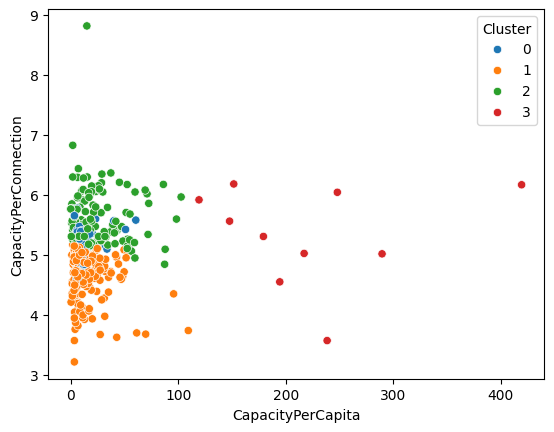

In [78]:
# Log scale for plotting
res_df['TotalPopulation'] = np.log(res_df['TotalPopulation'] )
res_df['PopulationDensity'] = np.log(res_df['PopulationDensity'] )

sns.scatterplot(data=res_df,
                x='CapacityPerCapita',
                y='CapacityPerConnection',
                hue='Cluster',
                palette = sns.color_palette("tab10"))

Finally, the plot below shows the clusters projected onto population factors. 

/var/folders/hv/06ql3rk924l7p8lskj2gfm740000gn/T/ipykernel_14665/1554307933.py:1: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.scatterplot(data=res_df,


<Axes: xlabel='MedianEquivalisedHouseholdIncome', ylabel='PopulationDensity'>

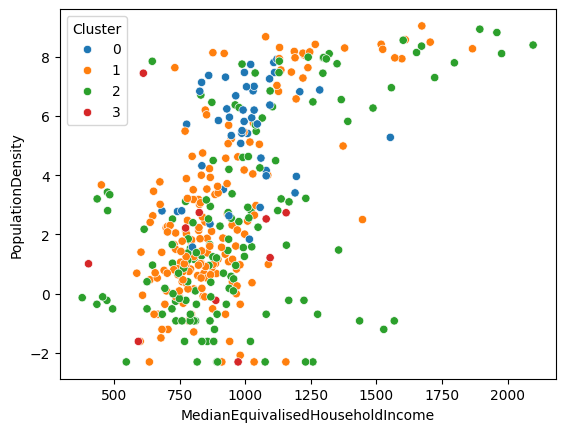

In [79]:
sns.scatterplot(data=res_df,
                x='MedianEquivalisedHouseholdIncome',
                y='PopulationDensity',
                hue='Cluster',
                palette = sns.color_palette("tab10")
                )

/var/folders/hv/06ql3rk924l7p8lskj2gfm740000gn/T/ipykernel_14665/2718818124.py:1: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.scatterplot(data=res_df,


<Axes: xlabel='TotalPopulation', ylabel='MedianAge'>

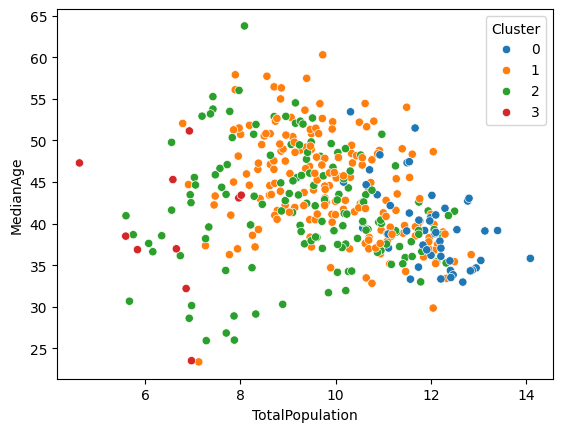

In [80]:
sns.scatterplot(data=res_df,
                x='TotalPopulation',
                y='MedianAge',
                hue='Cluster',
                palette = sns.color_palette("tab10"))

Unfortunately, neither plots show clear socioeconomic driver behind the clusters. Any predictive power from socioeconomic and economic data requires further analysis.

Regardless, we use DERR components to interpret the clusters. An interpretation is as follows:

**Residential Clusters**
- Cluster 0: Reluctant Adoption. Low capacity per capita and low growth rate. 
- Cluster 1: Low Quality Steady Adoption. Low capacity per connection, moderate capacity per capita and growth rate. 
- Cluster 2: High Quality Stead Adoption. High capacity per connection, moderate capacity per capita and growth rate. 
- Cluster 3: Enthusiastic Adoption. High capacity per capita (>100 kVA/capita) and high growth rate. 
        



### Businesses Data

The plot below shows the clusters in the business data  projected onto the first and second principle components. 

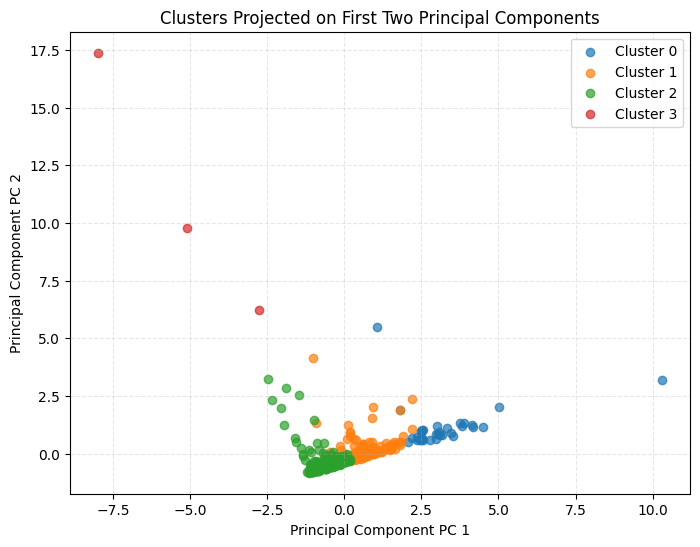

PCA vectors as a linear combination of factors
   TotalCapacity  TotalDerConnections  CapacityPerCapita  \
0       0.534471             0.540810          -0.463962   
1       0.459090             0.446092           0.487412   
2      -0.052076            -0.101934          -0.255900   

   CapacityPerConnection  GrowthRate  
0              -0.088575   -0.445824  
1               0.264448    0.531728  
2               0.953666   -0.109242  


In [92]:
cluster_projection(
    df_pca=bus_pca,
    df_cluster=bus_df,
    axis_x=1,axis_y=2
    )

print("PCA vectors as a linear combination of factors")
print(res_vecs)

The plot below shows the clusters projected onto capacity per capita and connections per capita. 

/var/folders/hv/06ql3rk924l7p8lskj2gfm740000gn/T/ipykernel_14665/4205519289.py:4: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.scatterplot(data=bus_df,


<Axes: xlabel='CapacityPerCapita', ylabel='CapacityPerConnection'>

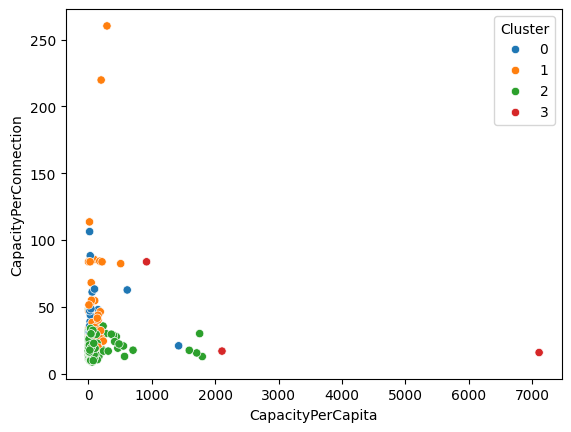

In [82]:
# Normalise for plotting
bus_df['TotalBusinesses'] = np.log(bus_df['TotalBusinesses'] )

sns.scatterplot(data=bus_df,
                x='CapacityPerCapita',
                y='CapacityPerConnection',
                hue='Cluster',
                palette = sns.color_palette("tab10"))

The next plots shows the clusters projected onto economic factors including, primary industry, small businesses and medium businesses metrics. 


/var/folders/hv/06ql3rk924l7p8lskj2gfm740000gn/T/ipykernel_14665/323026302.py:1: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.scatterplot(data=bus_df,


<Axes: xlabel='PrimaryIndustry', ylabel='SmallBusinesses'>

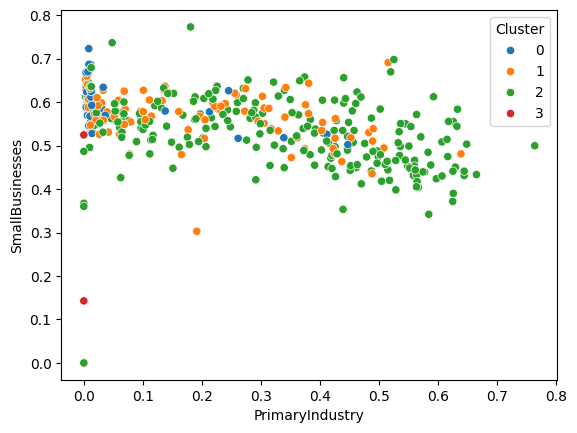

In [83]:
sns.scatterplot(data=bus_df,
                x='PrimaryIndustry',
                y='SmallBusinesses',
                hue='Cluster',
                palette = sns.color_palette("tab10"))

/var/folders/hv/06ql3rk924l7p8lskj2gfm740000gn/T/ipykernel_14665/1182692020.py:1: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.scatterplot(data=bus_df,


<Axes: xlabel='MediumBusinesses', ylabel='LargeBusinesses'>

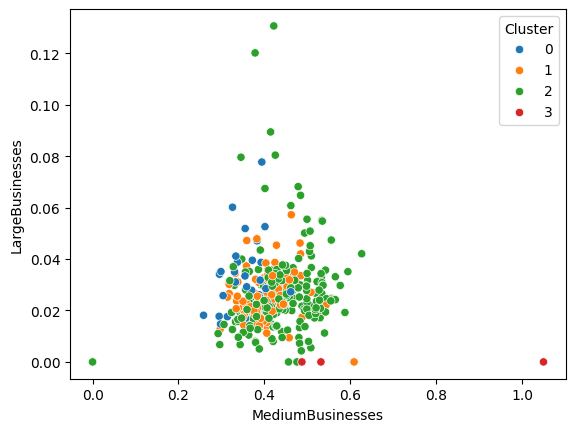

In [84]:
sns.scatterplot(data=bus_df,
                x='MediumBusinesses',
                y='LargeBusinesses',
                hue='Cluster',
                palette = sns.color_palette("tab10"))

Projecting the clusters onto industry data does not reveal any obvious interpretation of these clusters based on socioeconomic data. Further analysis wold be required to establish predictive power. 

Instead, an interpretation of clusters can be made by looking at DERR components only. We suggest the following. 

**Business Clusters**
- Cluster 0: Saturated. Low growth. High total capacity and connections. High capacity per capita.  
- Cluster 1: Steady Adoption. Low growth. Medium total capacity and connections. Medium capacity per capita.  
- Cluster 2: Reluctant Adoption. Low growth. Low total capacity and connections. Low capacity per capita.  
- Cluster 3: New Adoption. High growth, low total capacity and connections. 

### Updating SQL Database

In this last section, the clusters are added to the database. The clusters will be used in the powerBI dashboard. 

In [85]:
import sqlite3 as sql

# --- Data to add to Fact_Der Table --- #
cols = ['Lga','Type','GrowthRate','Cluster']
new_data = pd.concat([bus_df[cols], res_df[cols]], axis = 0,ignore_index=True)


# --- Add Data to SQL database --- #
DBPATH = '../data/sql_db/energy.db'

# Connect 
conn = sql.connect(DBPATH)
cur = conn.cursor()

# # New data as new table
# new_data.to_sql('new_data', conn, if_exists='replace',index=False)

# Queires

Q_copy = """ 
    CREATE TABLE IF NOT EXISTS Fact_Derr_Extended AS
    SELECT * FROM Fact_Derr
"""

Q_insert_data = """ 
    UPDATE Fact_Derr_Extended
    SET 
        GrowthRate = ?,
        Cluster = ?
    WHERE 
        Lga = ? AND 
        Type = ?
"""

# Execute queries

cur.execute("DROP TABLE IF EXISTS Fact_Derr_Extended")
cur.execute(Q_copy)

cur.execute("ALTER TABLE Fact_Derr_Extended ADD COLUMN GrowthRate REAL")
cur.execute("ALTER TABLE Fact_Derr_Extended ADD COLUMN Cluster INTEGER")

for idx in range(0,new_data.shape[0]):
    cur.execute(
        Q_insert_data,
        (new_data.loc[idx,'GrowthRate'],
         int(new_data.loc[idx,'Cluster']),
         new_data.loc[idx,'Lga'],
         new_data.loc[idx,'Type'])
        )
    
Fact_Derr_Extended_df = pd.read_sql("SELECT * FROM Fact_Derr_Extended",conn)

conn.close()


In [86]:
# Save extended der as parquet (issues loading into powerbi form sql database)
SAVEDIR = "../data/sql_db"
Fact_Derr_Extended_df.to_parquet(SAVEDIR+"/Fact_Derr_Extended.parquet")

In [87]:
Q_cast_dtype = """ 
    CREATE VIEW Fact_Derr_Ext_Cast AS
    SELECT 
        Year,
        Lga,
        Type,
        CAST(TotalCapacity AS REAL) AS TotalCapacity,
        CAST(BatteryCapacity AS REAL) AS BatteryCapacity,
        CAST(SolarCapacity AS REAL) AS SolarCapacity,
        CAST(OtherCapacity AS REAL) AS OtherCapacity,
        CAST(TotalDerConnections AS INTEGER) AS TotalDerConnections,
        CAST(BatteryConnections AS INTEGER) AS BatteryConnections,
        CAST(SolarConnections AS INTEGER) AS SolarConnections,
        CAST(OtherConnections AS INTEGER) AS OtherConnections,
        CAST(GrowthRate AS REAL) AS GrowthRate,
        CAST(Cluster AS INTEGER) AS Cluster
    FROM Fact_Derr_Extended
"""

In [88]:

conn = sql.connect(DBPATH)
cur = conn.cursor()
    
cur.execute("DROP VIEW IF EXISTS Fact_Derr_Ext_Cast")
cur.execute(Q_cast_dtype)

conn.close()